# Интерпретация

## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 


## Подготовка данных и моделей

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

# Загрузка данных 
data = pd.read_csv("data_unreg.csv")

# Признаки
num_features = [
    "location_marketplace_cnt",
    "location_amenity_pharmacy_w_mean_distance",
    "location_public_transport_stop_position_cnt",
    "location_college_cnt",
    "location_railway_cnt",
    "location_logs_count_std",
    "location_leisure_cnt",
    "location_shop_product_w_mean_distance",
    "location_public_transport_platform_w_mean_distance",
    "location_leisure_w_mean_distance",
    "location_flash_mean_mean",
    "location_market_cnt",
    "location_barrier_w_mean_distance",
]
cat_features = [
    "region_name_cat", "class_cat", "district_cat",
    "hc_name_cat", "developer_cat", "corpus_cat", "stage_cat",
]

X = data.drop(columns=["price_target"])
y = data["price_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Pipeline-модели
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  MinMaxScaler()),
])
cat_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
])

lin_model = Pipeline([("preprocessor", preprocessor),
                       ("model", LinearRegression())])
gb_model  = Pipeline([("preprocessor", preprocessor),
                       ("model", GradientBoostingRegressor(max_depth=5, random_state=42))])

lin_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("Модели обучены")
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")


Модели обучены
  Train: (23924, 82)  |  Test: (5981, 82)


## Задание 7 - локальный SHAP

=== SHAP - GradientBoosting ===


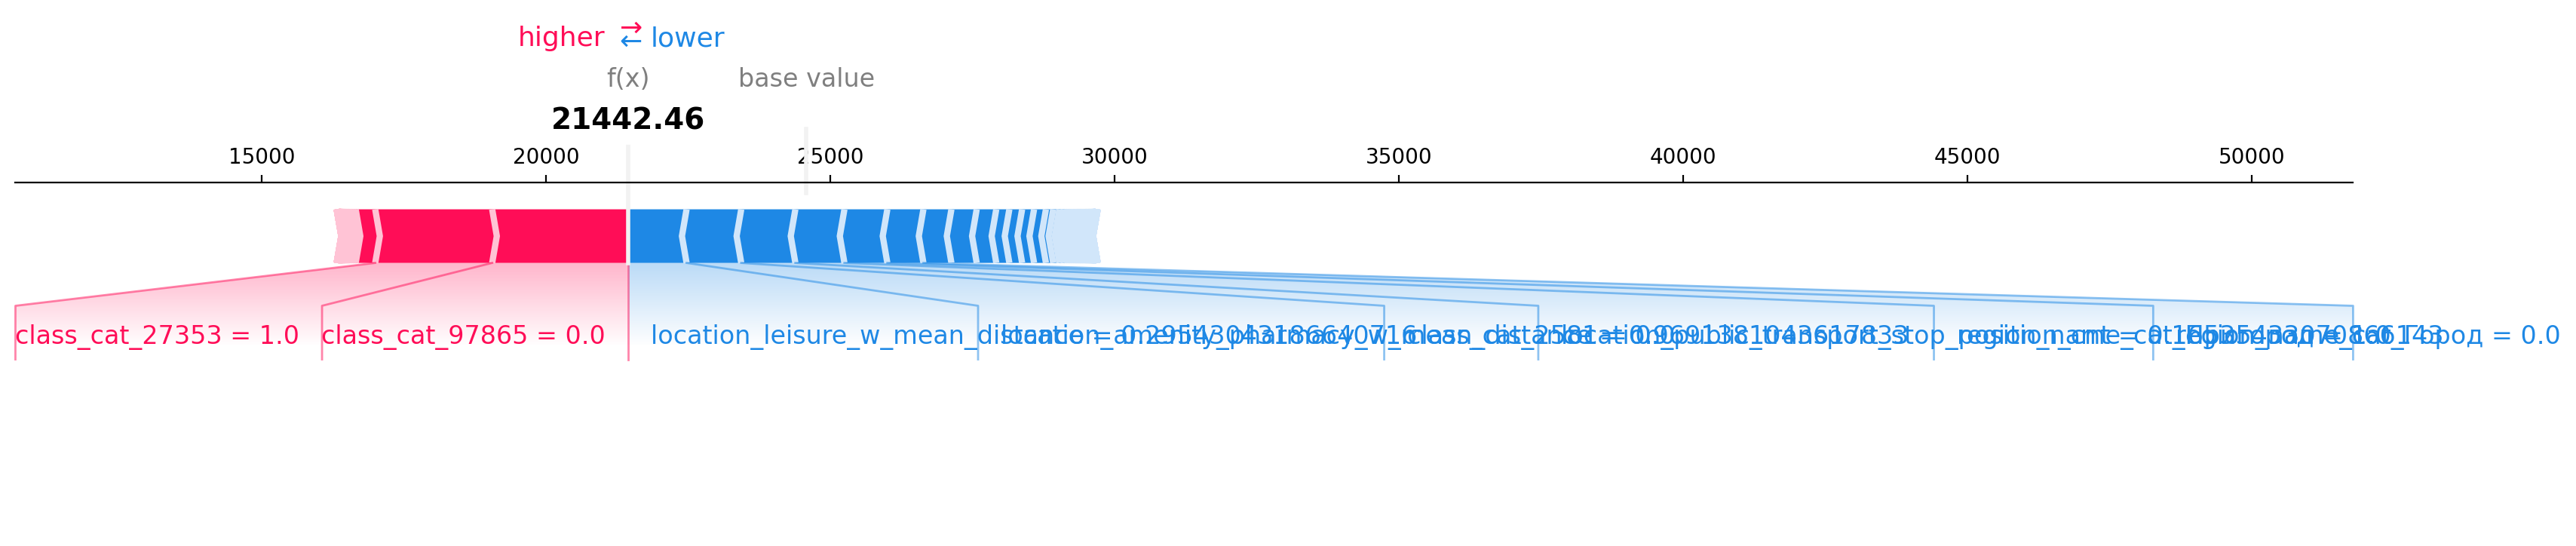

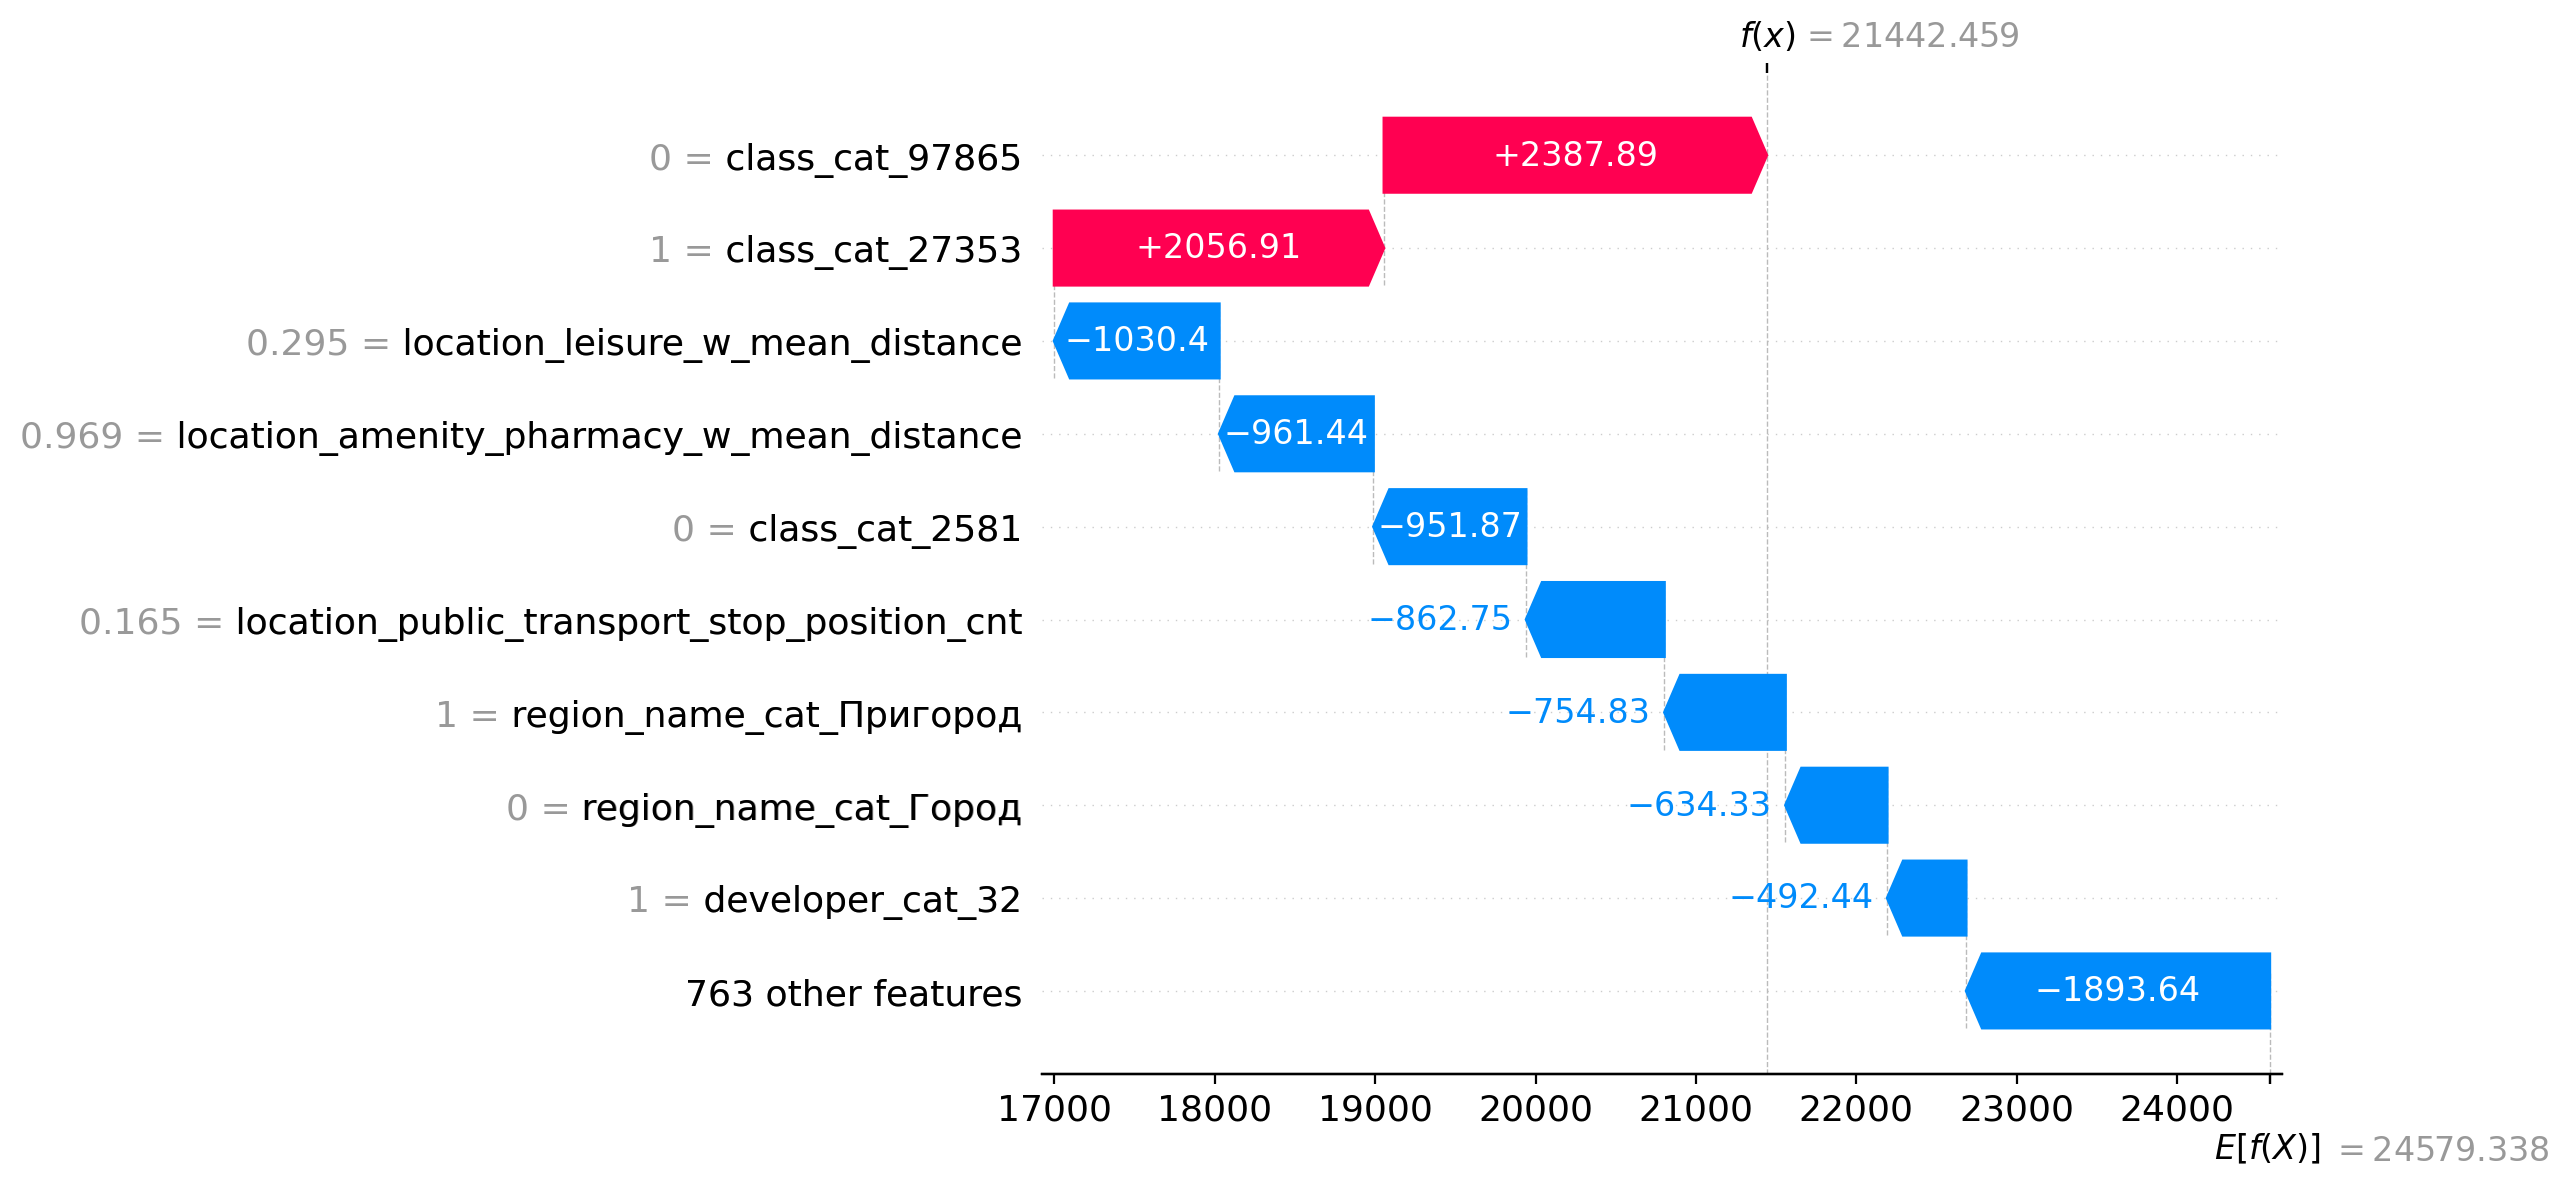


=== SHAP - LinearRegression ===


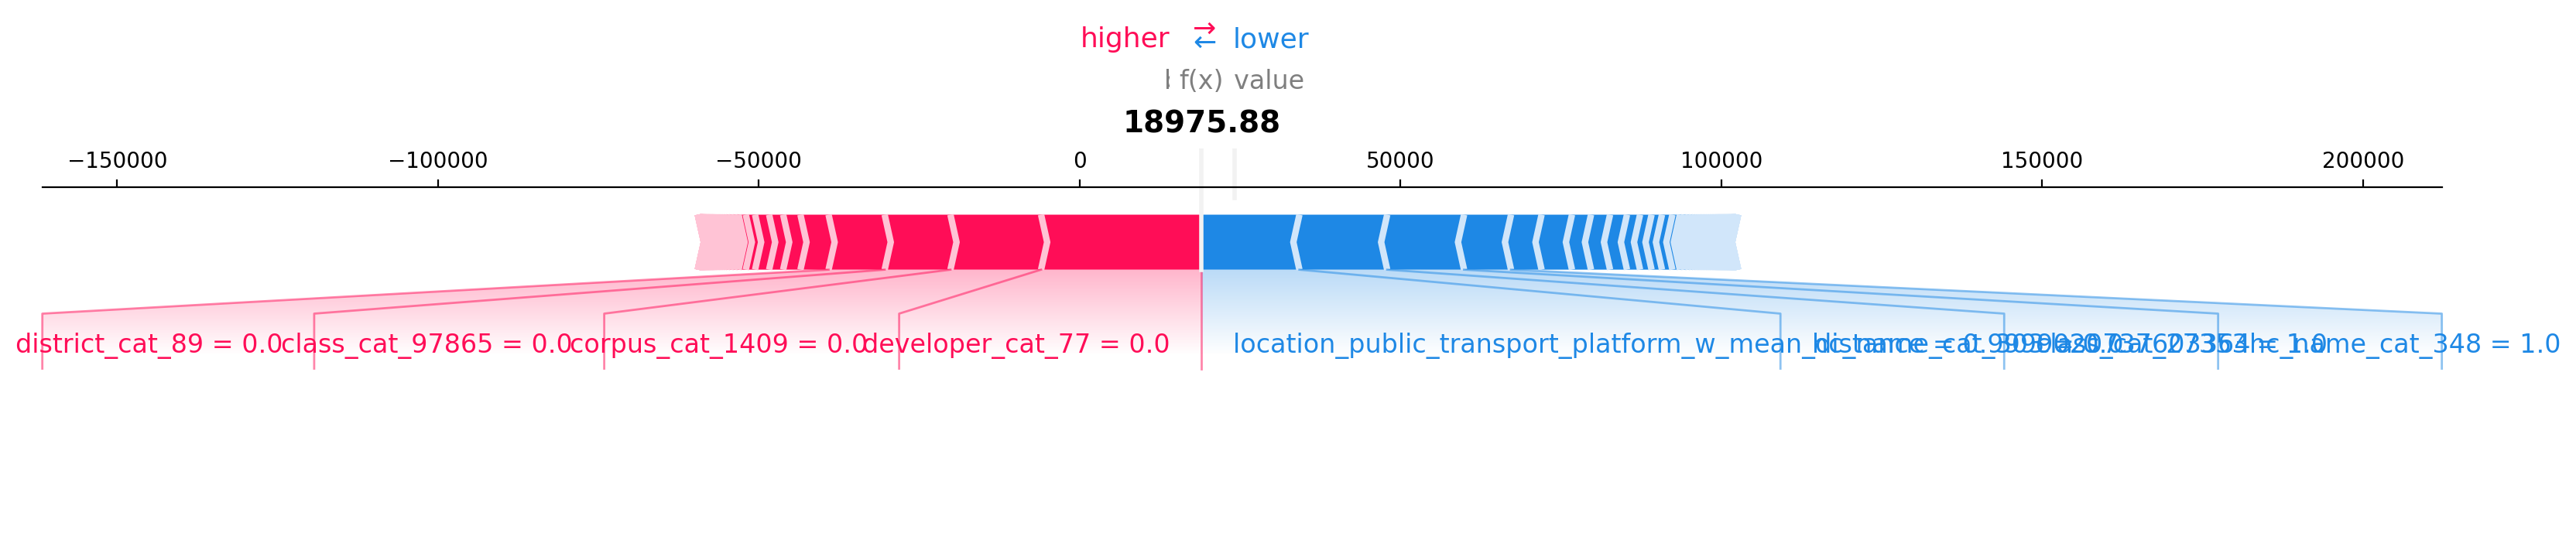

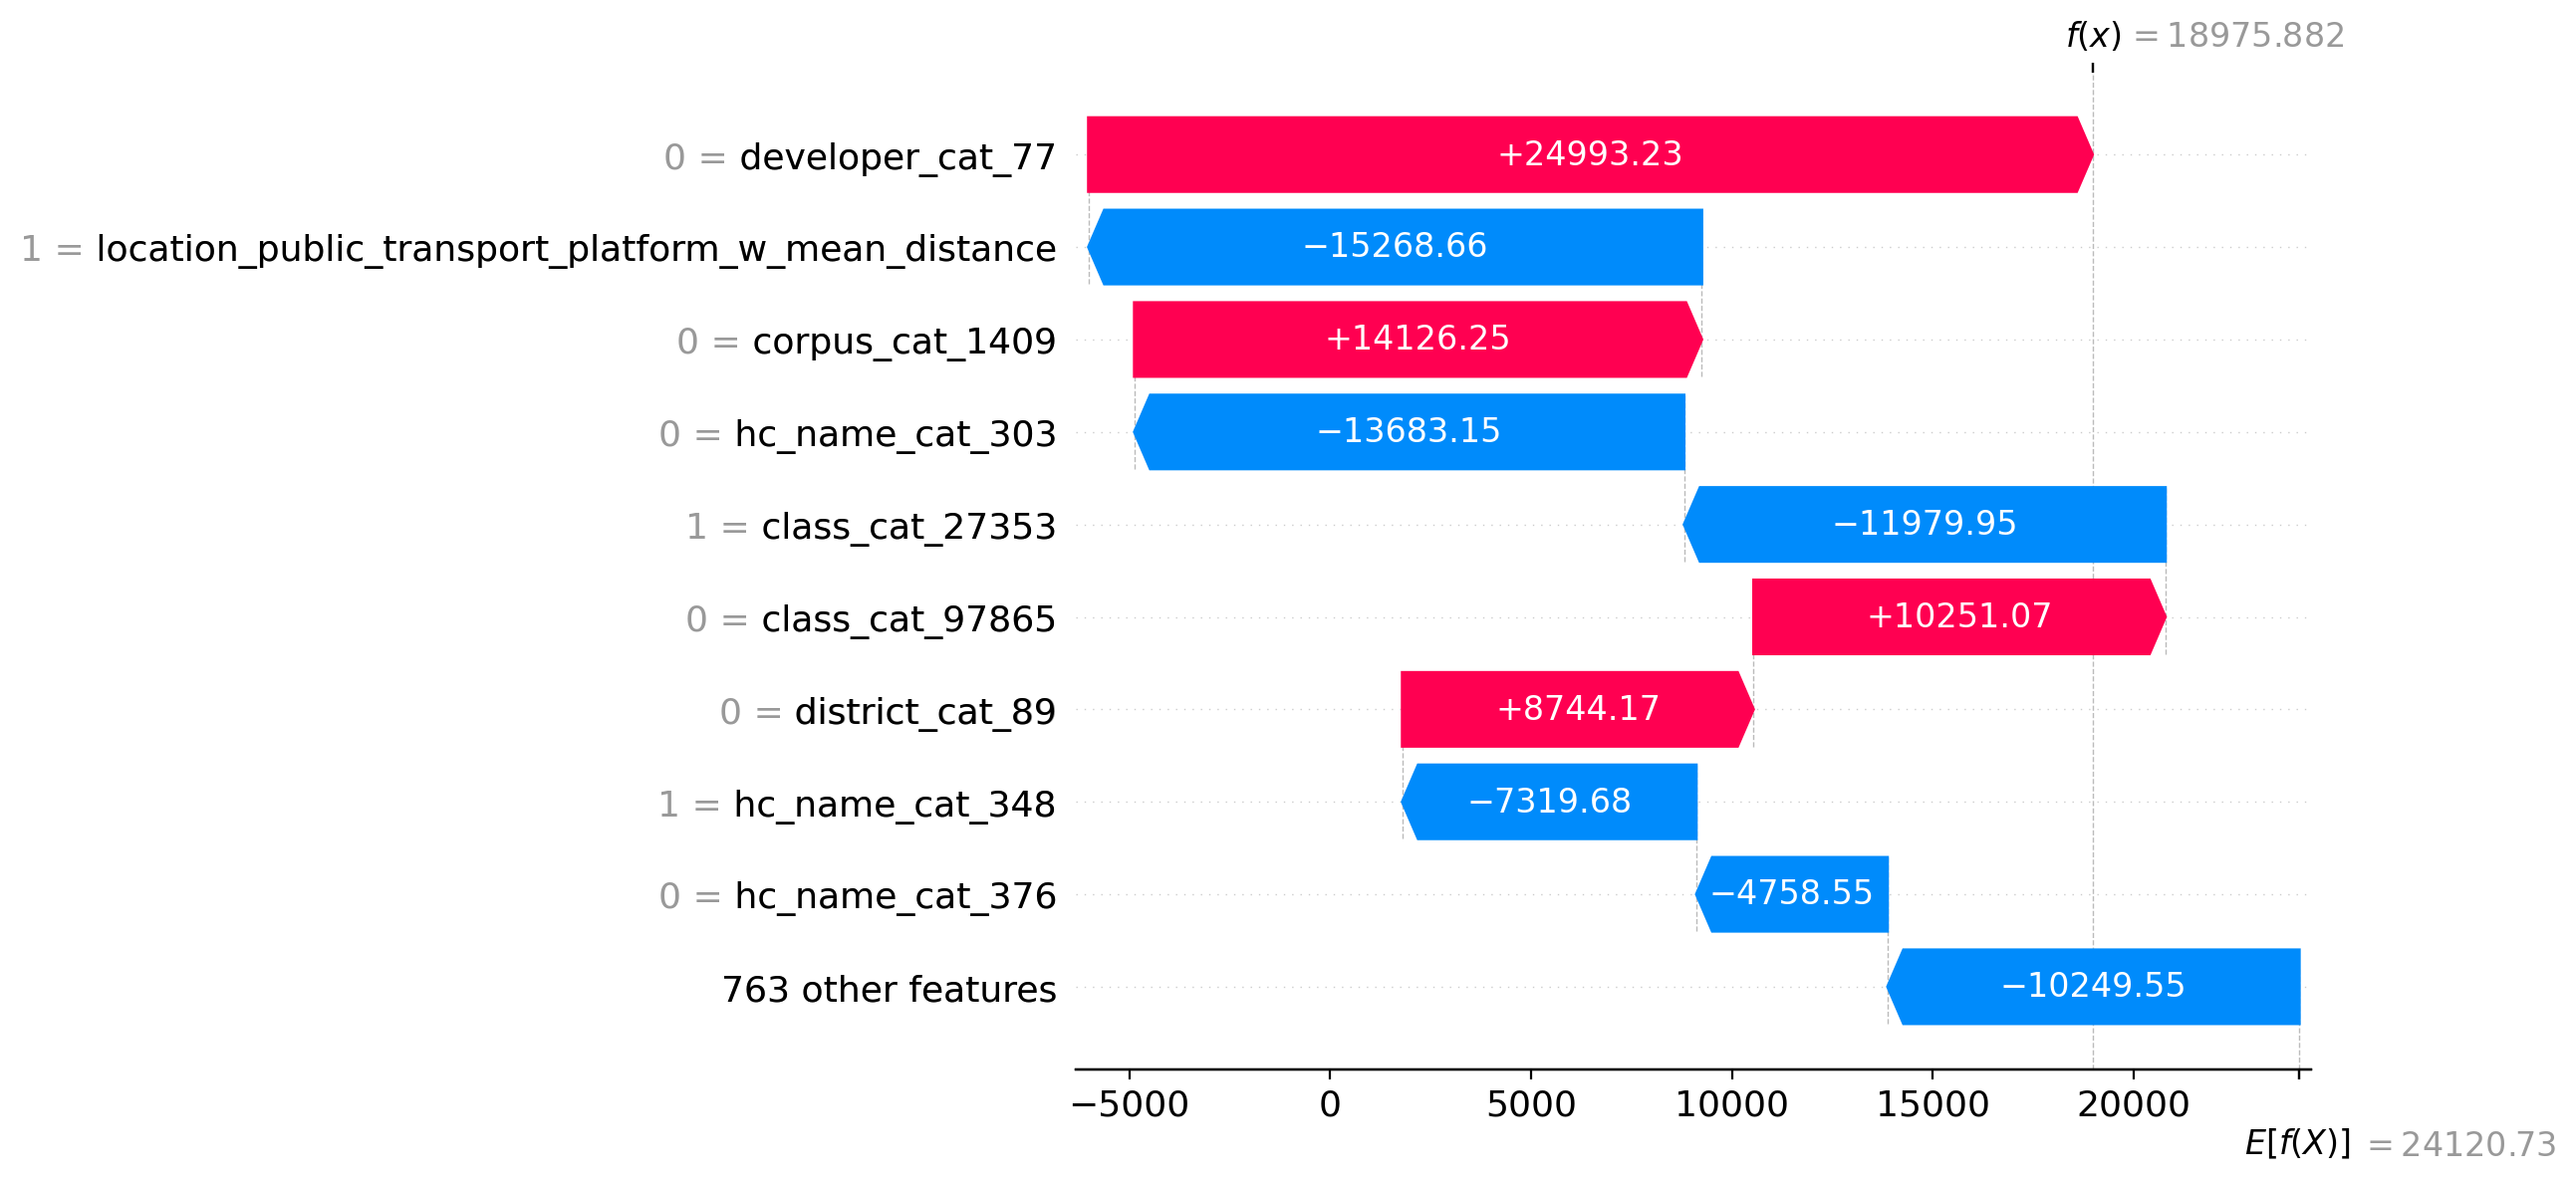

In [2]:
import shap

preprocessor_fitted = gb_model.named_steps["preprocessor"]
gb_inner            = gb_model.named_steps["model"]
lin_inner           = lin_model.named_steps["model"]

X_train_t = preprocessor_fitted.transform(X_train)
X_test_t  = preprocessor_fitted.transform(X_test)

ohe_names = (preprocessor_fitted
             .named_transformers_["cat"]["encoder"]
             .get_feature_names_out(cat_features))
all_feature_names = list(num_features) + list(ohe_names)

student_idx = 17

# GradientBoosting
explainer_gb = shap.TreeExplainer(gb_inner)
shap_vals_gb = explainer_gb.shap_values(X_test_t)

print("=== SHAP - GradientBoosting ===")
shap.force_plot(
    explainer_gb.expected_value, shap_vals_gb[student_idx],
    X_test_t[student_idx], feature_names=all_feature_names,
    matplotlib=True, show=True)
shap.waterfall_plot(shap.Explanation(
    values=shap_vals_gb[student_idx],
    base_values=explainer_gb.expected_value,
    data=X_test_t[student_idx],
    feature_names=all_feature_names))

# LinearRegression
explainer_lin = shap.LinearExplainer(lin_inner, X_train_t)
shap_vals_lin = explainer_lin.shap_values(X_test_t)

print("\n=== SHAP - LinearRegression ===")
shap.force_plot(
    explainer_lin.expected_value, shap_vals_lin[student_idx],
    X_test_t[student_idx], feature_names=all_feature_names,
    matplotlib=True, show=True)
shap.waterfall_plot(shap.Explanation(
    values=shap_vals_lin[student_idx],
    base_values=explainer_lin.expected_value,
    data=X_test_t[student_idx],
    feature_names=all_feature_names))


### Анализ

**GradientBoosting** (f(x) = 21 442, base = 24 579):

Предсказание ниже среднего. Два dummy-столбца `class_cat` тянут вверх:
`class_cat_97865 = 0` (+2388) и `class_cat_27353 = 1` (+2057) - объект
принадлежит к определённому классу жилья, и это повышает цену относительно
среднего. Против работают несколько признаков: `location_leisure_w_mean_distance`
(−1030), `location_amenity_pharmacy_w_mean_distance` (−961), `region_name_cat_Пригород = 1`
(−755) - объект в пригороде, что снижает цену. Итого: локация объекта
(пригород, далеко от инфраструктуры) перевешивает класс жилья.

**LinearRegression** (f(x) = 18 976, base = 24 121):

Предсказание тоже ниже среднего, но картина значительно более «шумная» -
крупные разнонаправленные вклады взаимно компенсируются. Доминирует
`developer_cat_77 = 0` (+24 993), но его почти полностью гасит
`location_public_transport_platform_w_mean_distance = 1` (−15 269)
и `hc_name_cat_303 = 0` (−13 683). Такие огромные вклады с разными знаками -
признак мультиколлинеарности: линейная регрессия компенсирует корреляции
между dummy-столбцами за счёт экстремальных коэффициентов, что делает
локальную интерпретацию ненадёжной.

**Сравнение моделей:**
GradientBoosting даёт компактное, стабильное объяснение - несколько признаков
с умеренными вкладами. LinearRegression - десятки признаков с гигантскими
взаимоуничтожающимися вкладами. Для интерпретации конкретного объекта
SHAP + GradientBoosting значительно информативнее.

## Задание 7.1 - SHAP и категориальные переменные

Объект 17 | f(x) = 21442.46

Признак                ДО (сумма = вклад целиком)  ПОСЛЕ (вклады dummy-столбцов)
region_name_cat                        -1389.1575  Город=-634.33  Пригород=-754.83
class_cat                              +3492.9382  2581=-951.87  27353=+2056.91  97865=+2387.89
district_cat                            -295.9091  3=-10.92  4=+0.24  6=+0.19  7=+2.31
hc_name_cat                             -389.1240  8=-0.04  12=-0.11  16=-5.57  35=-0.66
developer_cat                           -508.4729  2=-11.96  4=+2.70  9=-10.42  10=+1.53
corpus_cat                               -20.6949  107=-0.18  126=-0.17  134=+0.25  146=+0.02
stage_cat                               -129.1525  103=-0.01  2665=-23.80  2700=-21.23  3321=+0.17


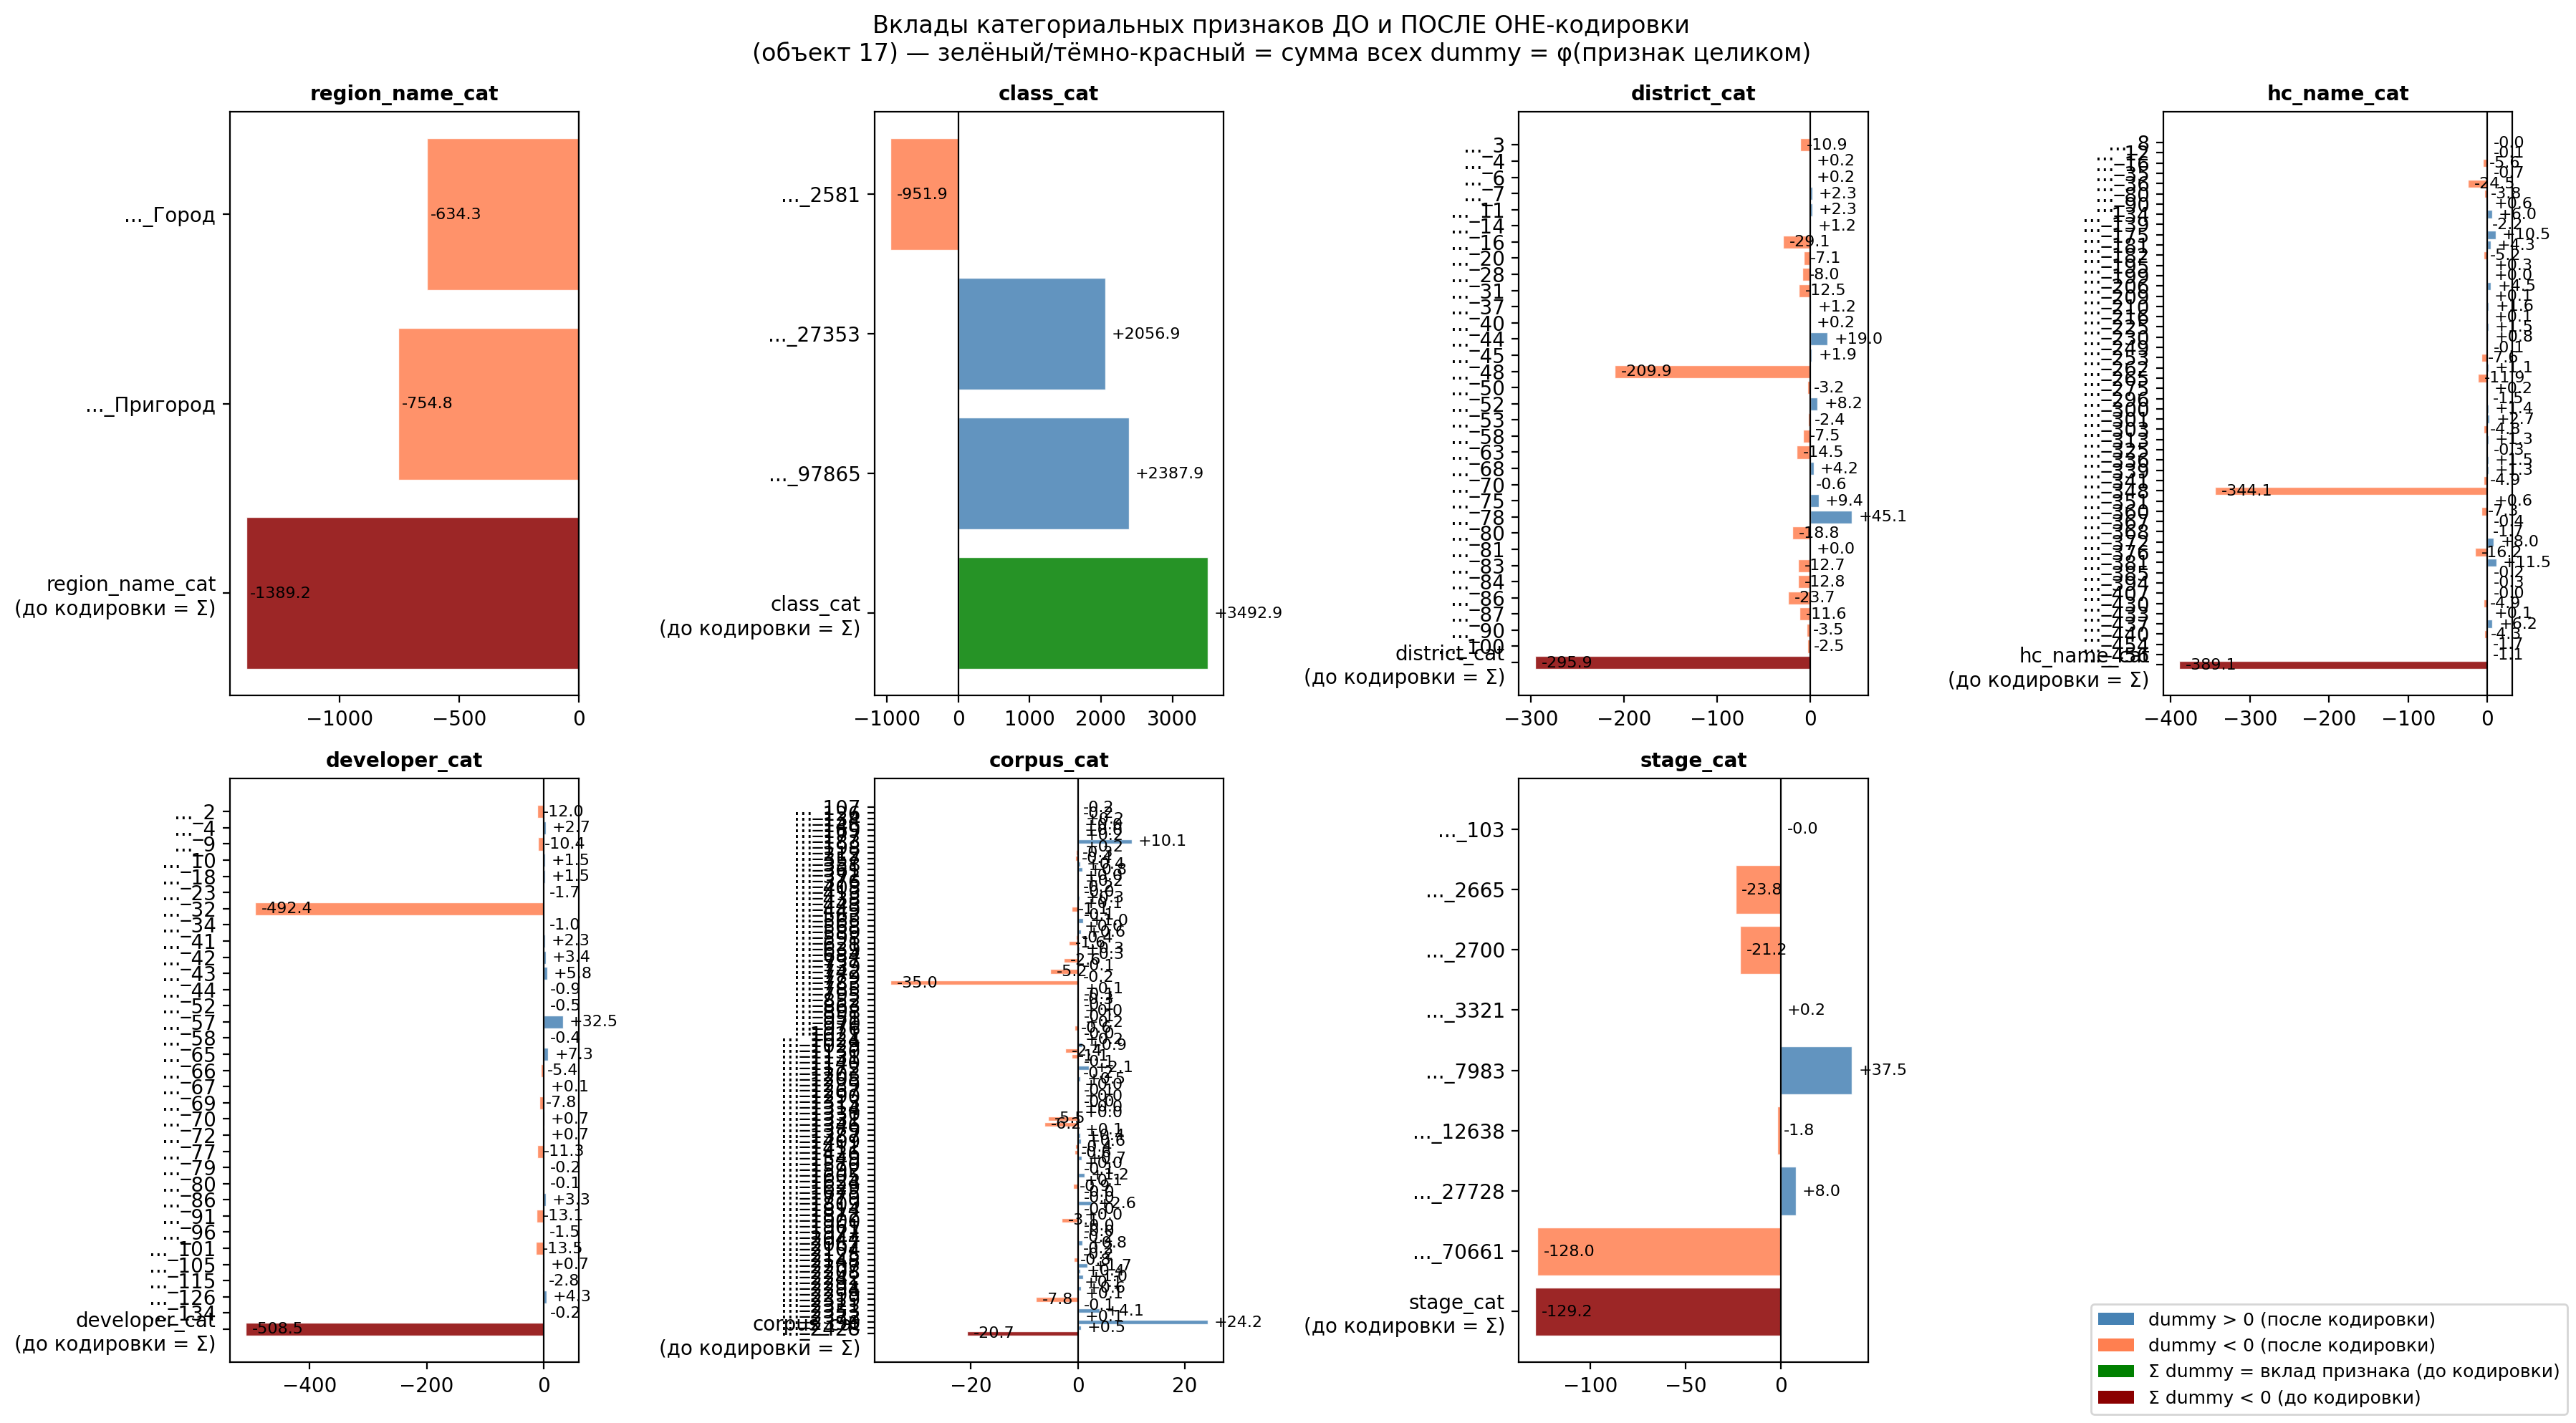

In [3]:
# Задание 7.1: SHAP и категориальные переменные
# Проверяем внутри одной OHE-модели:
# φ(cat_feature) == Σ φ(cat_feature_k)?
#
# До кодировки  = φ(cat_feature) как целого = Σ φ(dummy_k)
# После кодировки = отдельные вклады каждого dummy-столбца

ohe_names_list = list(all_feature_names)

print(f"Объект {student_idx} | f(x) = {float(explainer_gb.expected_value) + shap_vals_gb[student_idx].sum():.2f}\n")

# Таблица: до vs после 
print(f"{'Признак':<20} {'ДО (сумма = вклад целиком)':>28}  ПОСЛЕ (вклады dummy-столбцов)")
print("=" * 90)

totals = {}
breakdown = {}
for cat_feat in cat_features:
    dummy_names = [n for n in ohe_names_list if n.startswith(cat_feat + "_")]
    dummy_idx   = [ohe_names_list.index(n) for n in dummy_names]
    dummy_shap  = shap_vals_gb[student_idx][dummy_idx]
    total       = dummy_shap.sum()
    totals[cat_feat]    = total
    breakdown[cat_feat] = list(zip(dummy_names, dummy_shap))

    nonzero = [(n, v) for n, v in zip(dummy_names, dummy_shap) if abs(v) > 0.01]
    nonzero_str = "  ".join(
        f"{n.replace(cat_feat + '_', '')}={v:+.2f}" for n, v in nonzero[:4])
    if not nonzero_str:
        nonzero_str = "все = 0"
    print(f"{cat_feat:<20} {total:>+28.4f}  {nonzero_str}")

# График: сравнение до и после для каждого признака
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, cat_feat in enumerate(cat_features):
    ax = axes[i]
    dummy_names = [n for n in ohe_names_list if n.startswith(cat_feat + "_")]
    dummy_idx   = [ohe_names_list.index(n) for n in dummy_names]
    dummy_shap  = shap_vals_gb[student_idx][dummy_idx]
    total       = dummy_shap.sum()

    # ненулевые dummy + итоговый бар до кодировки
    nonzero_mask = np.abs(dummy_shap) > 0.01
    after_names = [n.replace(cat_feat + "_", "..._") for n in
                   np.array(dummy_names)[nonzero_mask]]
    after_vals  = list(dummy_shap[nonzero_mask])

    all_names = after_names + [f"{cat_feat}\n(до кодировки = Σ)"]
    all_vals  = after_vals  + [total]
    colors    = (["steelblue" if v > 0 else "coral" for v in after_vals]
                 + ["green" if total > 0 else "darkred"])

    ax.barh(all_names, all_vals, color=colors, alpha=0.85,
            edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(cat_feat, fontsize=10, fontweight="bold")
    ax.invert_yaxis()

    # Подписи
    for bar, val in zip(ax.patches, all_vals):
        ax.text(val + (max(all_vals) - min(all_vals)) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{val:+.1f}", va="center", fontsize=8)

axes[-1].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="dummy > 0 (после кодировки)"),
    Patch(facecolor="coral",     label="dummy < 0 (после кодировки)"),
    Patch(facecolor="green",     label="Σ dummy = вклад признака (до кодировки)"),
    Patch(facecolor="darkred",   label="Σ dummy < 0 (до кодировки)"),
]
fig.legend(handles=legend_elements, loc="lower right", fontsize=9)
fig.suptitle(
    f"Вклады категориальных признаков ДО и ПОСЛЕ OHE-кодировки\n"
    f"(объект {student_idx}) — зелёный/тёмно-красный = сумма всех dummy = φ(признак целиком)",
    fontsize=12)
plt.tight_layout()
plt.show()


### Анализ

**Так ли это?** Да, свойство φ(cat) = Σ φ(dummy_k) подтверждается для всех признаков.
Зелёный/тёмно-красный бар на каждом графике точно равен сумме остальных баров.

**Что видно по конкретным признакам:**

- **region_name_cat** (−1389): оба уровня ненулевые - `Город` (−634) и `Пригород` (−755).
  Объект находится в пригороде, и оба dummy активно снижают предсказание.
  Это один из редких случаев, когда несколько dummy вносят заметный вклад.

- **class_cat** (+3493): три ненулевых уровня с разными знаками - `2581` (−952),
  `27353` (+2057), `97865` (+2388). Класс жилья - самый влиятельный категориальный
  признак для этого объекта, суммарно повышает цену почти на 3500 руб/м².

- **district_cat** (−296) и **hc_name_cat** (−389): много ненулевых dummy с малыми
  вкладами, которые в сумме дают умеренный отрицательный эффект. Ни один уровень
  не доминирует.

- **developer_cat** (−508): `developer_32` (−492) вносит почти весь вклад в одиночку -
  конкретный застройщик заметно снижает предсказанную цену.

- **corpus_cat** (−21) и **stage_cat** (−129): слабое влияние. В stage_cat выделяется
  `70661` (−128) - практически весь вклад признака.

**Вывод:** свойство выполняется точно. После кодировки вклад признака «раскладывается»
по уровням категории, но суммарный эффект сохраняется. Большинство признаков имеют
1–2 доминирующих уровня, остальные dummy близки к нулю.